# Uso de la api de Google GenAI 

In [1]:
pip install google-genai

   ---------------------------------------- 0.0/122.9 kB ? eta -:--:--
   ---------- ----------------------------- 30.7/122.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 122.9/122.9 kB 1.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from dotenv import load_dotenv
import os
load_dotenv('../.env')
from google import genai
from google.genai import types
import asyncio
import contextlib
import json
from IPython.display import Image, display, Markdown

model_name = 'gemini-2.0-flash-exp'

client = genai.Client(http_options={'api_version':'v1alpha'})
n=0
async def chatting(prompt:str, modality:str='TEXT', tools=None):
    global n 
    if tools is None:
        tools = []
    
    config = {
        'tools': tools,
        'generation_config': {
            'response_modalities': [modality],
        }
    }

    async with client.aio.live.connect(model=model_name, config=config) as session:
        await session.send(input=prompt, end_of_turn=True)
        bytes_data = b''
        complete_text_response = ''
        async for response in session.receive():
            if text:=response.text:
                display(Markdown(text))
                complete_text_response += text

            if data:=response.data:
                bytes_data += data

        def detect_kind_of_Bytes(data:bytes):
            """
            Detects the kind of file in data. If it is an image (in any format png, jpg, etc), write it to a file and return the path. 
            If it is audio, write it to a file and return the path.
            """
            if data[:4] == b'\x89PNG':
                kind = 'image/png'
            elif data[:2] == b'\xff\xd8':
                kind = 'image/jpeg'
            elif data[:4] == b'RIFF':
                kind = 'audio/wav'
            elif data[:3] == b'ID3' or data[:2] == b'\xff\xfb':
                kind = 'audio/mp3'
            elif data[:4] == b'LPCM':
                kind = 'audio/pcm'
            else:
                kind = 'mp3'
                with open(f'audio{n}.mp3', 'wb') as f:
                    f.write(data)
                return f'audio{n}.mp3'
            with open(f'output{n}.{kind.split("/")[-1]}', 'wb') as f:
                f.write(data)
            return f'output{n}.{kind.split("/")[-1]}'
        
        if bytes_data:
            n+=1
            path = detect_kind_of_Bytes(bytes_data)

            if path.split('.')[-1] in ['png', 'jpg', 'jpeg']:
                display(Image(filename=path))

            if path.split('.')[-1] in ['wav']:
                # Play the audio
                pass
        
        return complete_text_response
    







In [31]:
await chatting('What is the capital of France?')

The capital of France

 is **Paris**.


LiveServerMessage(setup_complete=None, server_content=LiveServerContent(model_turn=None, turn_complete=True, interrupted=None), tool_call=None, tool_call_cancellation=None)

Okay

, I understand. I will plot a Lorentzian peak using standard values for the parameters.

 Here's my plan:

1. **Choose Standard Parameter Values:**
   

- I'll need to select values for the center (x0), the height (A), and the half-width at half-maximum (HWHM

, often represented by gamma or γ).  I'll go with:
      - `x0` (center): 0
      - `A

...

 and gamma. The general formula for a Lorentzian is:

   

```
   L(x) = A * (gamma^2) / ((x - x0)^2 + gamma^2)
   ```



3. **Generate

 x Values:** I'll create a range of x values to plot, centered around x0.

4. **Calculate y Values:** I will use my function to compute the y-values corresponding to the x-values.

5. **Plotting using matplotlib:** I will plot the x and y values using matplotlib

, including axis labels and a title.

Here's the Python code to accomplish this:



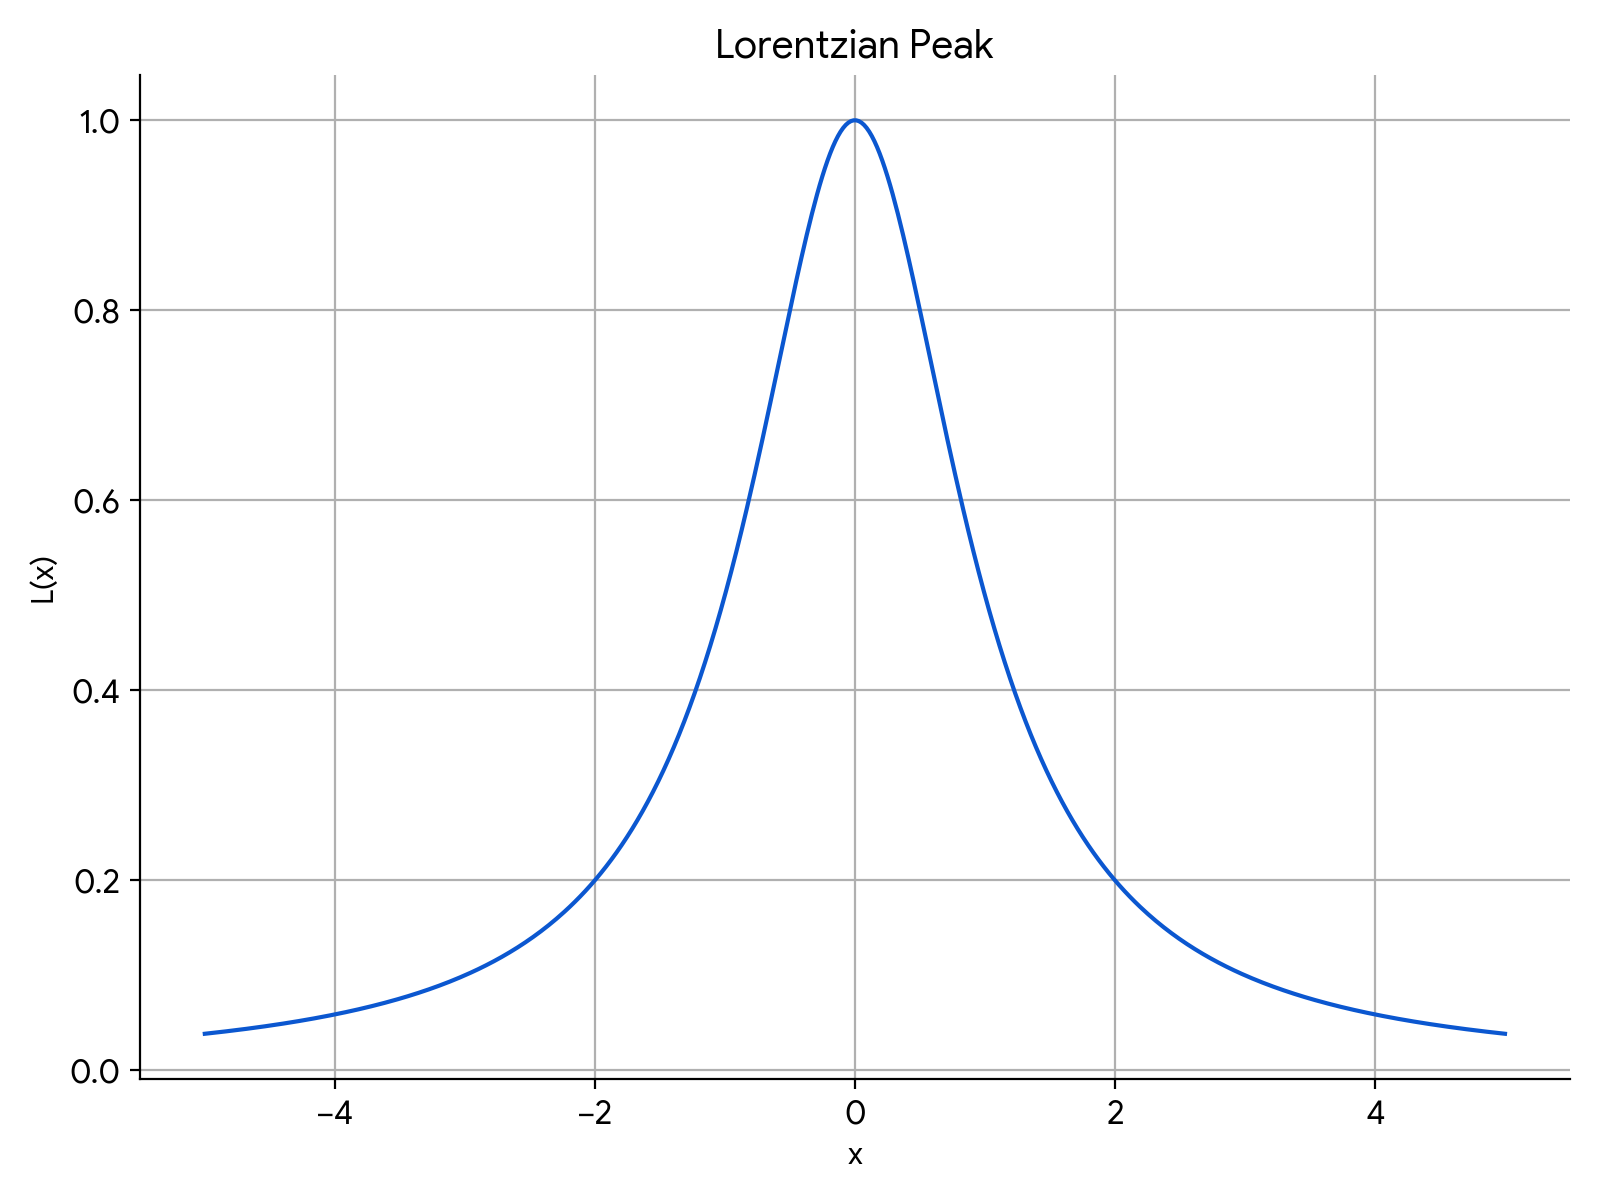

LiveServerMessage(setup_complete=None, server_content=LiveServerContent(model_turn=None, turn_complete=True, interrupted=None), tool_call=None, tool_call_cancellation=None)

In [32]:
tools = [
    {'code_execution':{}}
]
await chatting('Plot an image with a lorentizian peak. Use the standar values for every parameter, select them by yourself and make the plot. Do Not ask me for parameters', modality='TEXT', tools=tools)

In [41]:
tools = [
    {'code_execution':{}},
    {'google_search':{}}
]
response = await chatting('Busca en la web: ¿Cuáles han sido los más recientes mandatos del nuevo presidente de estados unidos de américa?', modality='TEXT', tools=tools)

The most

 recent executive orders from President Biden have covered a range of topics. Some key areas include

:

*   **Climate Change:** Several executive orders focus on addressing climate change

, including halting new oil leases, reviewing federal regulations related to the environment and energy, and directing the federal government to consider climate change in infrastructure investments. There are also efforts aimed

 at expanding environmental justice priorities.
*   **Equity and Inclusion:** There have been executive orders focused on advancing equity, justice, and opportunity for specific groups,

 such as Asian Americans, Native Hawaiians, and Pacific Islanders, as well as promoting diversity, equity, inclusion, and accessibility in the federal workforce. There are also actions aimed at strengthening protections against discrimination based on sex, sexual orientation, and gender

 identity in educational environments.
*   **Cybersecurity:** Some executive orders have been aimed at improving the nation's cybersecurity and strengthening and promoting innovation in that sector.
*   **Healthcare:** Executive actions related to healthcare have included strengthening

 Medicaid and the Affordable Care Act, loosening Medicaid enrollment rules, expanding ACA subsidies, and new nursing home staff requirements.
*   **Economic Policy:** Some executive orders have aimed to ensure government investments support American workers and businesses.

It's worth noting that the information available is from multiple sources and can be presented in different ways,

 so the order of executive orders and focus areas can vary slightly depending on the specific source. The search results also showed executive orders issued from the beginning of President Biden's term through early 2025.


In [43]:
display(Markdown(response))

The most recent executive orders from President Biden have covered a range of topics. Some key areas include:

*   **Climate Change:** Several executive orders focus on addressing climate change, including halting new oil leases, reviewing federal regulations related to the environment and energy, and directing the federal government to consider climate change in infrastructure investments. There are also efforts aimed at expanding environmental justice priorities.
*   **Equity and Inclusion:** There have been executive orders focused on advancing equity, justice, and opportunity for specific groups, such as Asian Americans, Native Hawaiians, and Pacific Islanders, as well as promoting diversity, equity, inclusion, and accessibility in the federal workforce. There are also actions aimed at strengthening protections against discrimination based on sex, sexual orientation, and gender identity in educational environments.
*   **Cybersecurity:** Some executive orders have been aimed at improving the nation's cybersecurity and strengthening and promoting innovation in that sector.
*   **Healthcare:** Executive actions related to healthcare have included strengthening Medicaid and the Affordable Care Act, loosening Medicaid enrollment rules, expanding ACA subsidies, and new nursing home staff requirements.
*   **Economic Policy:** Some executive orders have aimed to ensure government investments support American workers and businesses.

It's worth noting that the information available is from multiple sources and can be presented in different ways, so the order of executive orders and focus areas can vary slightly depending on the specific source. The search results also showed executive orders issued from the beginning of President Biden's term through early 2025.


In [44]:
tools = [
    {'google_search':{}}
]
response = await chatting('Quién es el actual presidente de EUA?', modality='TEXT', tools=tools)


El

 actual presidente de los Estados Unidos es Donald J. Trump. Asumió el cargo el

 20 de enero de 2025, después de haber ganado

 las elecciones presidenciales de 2024. Esta es su segundo mandato como presidente, habiendo servido previamente de 2017 a 20

21. El vicepresidente actual es JD Vance.


In [45]:
response = await chatting('Puedes NO responder en formato Markdown?', modality='TEXT', tools=tools)

Sí

, puedo responder sin usar formato Markdown. ¿En qué te puedo ayudar?


In [46]:
tools = [
    {'code_execution':{}},
    {'google_search':{}}
]
response = await chatting('Puedes crear una gráfica de los últimos 30 días del precio de apertura del índice S&P500 (Usa yfinance para importar los datos)', modality='TEXT', tools=tools)

Okay

, I can create a graph of the S&P 500'

s opening price for the last 30 days using `yfinance`. I

 will use `matplotlib` to plot the data.


Ah

...

, it appears I cannot directly use subprocess to install packages. I will assume that `yfinance

` is available, despite the previous errors.  I will try running the code again

 to generate the plot, and this time, instead of using `plt.show()`, I will focus on capturing the image as bytes so it can be presented

 without needing a display. I will also add some error handling. If this continues to fail due to import issues with yfinance, it's likely an environment

 limitation, and I'll need to adjust the response.


In [49]:
tools = [
    {'code_execution':{}},
    {'google_search':{}}
]
response = await chatting('Calcula el número primo palíndromo más grande menor de 10000', modality='TEXT', tools=tools)

Ok

, vamos a resolver esto. Necesito encontrar el número primo palíndromo más

 grande que sea menor que 10000. Esto implica dos comprob

aciones: si un número es palíndromo (se lee igual de izquierda a derecha que de derecha a izquierda) y si es primo (solo divisible por 1

 y sí mismo).

Primero, crearé una función para comprobar si un número es palíndromo. Luego, una para comprobar si es primo, y finalmente

 iteraré hacia abajo desde 10000, comprobando cada número hasta que encuentre un número primo palíndromo.


El

 número primo palíndromo más grande menor que 10000

 es 929.


In [51]:
tools = [
    {'code_execution':{}},
    {'google_search':{}}
]
response = await chatting('Enlista todas las dependencias que tienes disponibles para hacer ejecución de código. Cómo se pueden configurar más dependencias? Por ejemplo si quisiera usar yfinance?', modality='TEXT', tools=tools)

Las

 dependencias disponibles para la ejecución de código son:

*   `chess`
*   `cv2`
*   `matplotlib`
*   

`mpmath`
*   `numpy`
*   `pandas`
*   `pdfminer`
*   `reportlab`
*   

`seaborn`
*   `sklearn`
*   `statsmodels`
*   `striprtf`
*   `sympy`
*

   `tabulate`

Actualmente, la configuración de dependencias adicionales, como `yfinance`, no está disponible directamente a través de prompts. Estas dependencias predefinidas están configuradas para garantizar un entorno seguro y estable para la

 ejecución de código. La capacidad de agregar dependencias externas como `yfinance` no está soportada.


Por supuesto.

 Primero, voy a cargar el conjunto de datos de cáncer de mama de scikit-learn y

 crearé un modelo de Random Forest, para luego mostrar la gráfica de la evaluación

.



OK

. Aquí está la gráfica de la curva ROC (Receiver Operating Characteristic) como se

 solicitó, generada usando el modelo Random Forest entrenado con el conjunto de datos de

 cáncer de mama de scikit-learn. La curva ROC ilustra el rendimiento del modelo en diferentes umbrales de clasificación. El área bajo la curva (

AUC) se proporciona en la leyenda, indicando el poder discriminatorio general del modelo (más cercano a 1 es mejor).


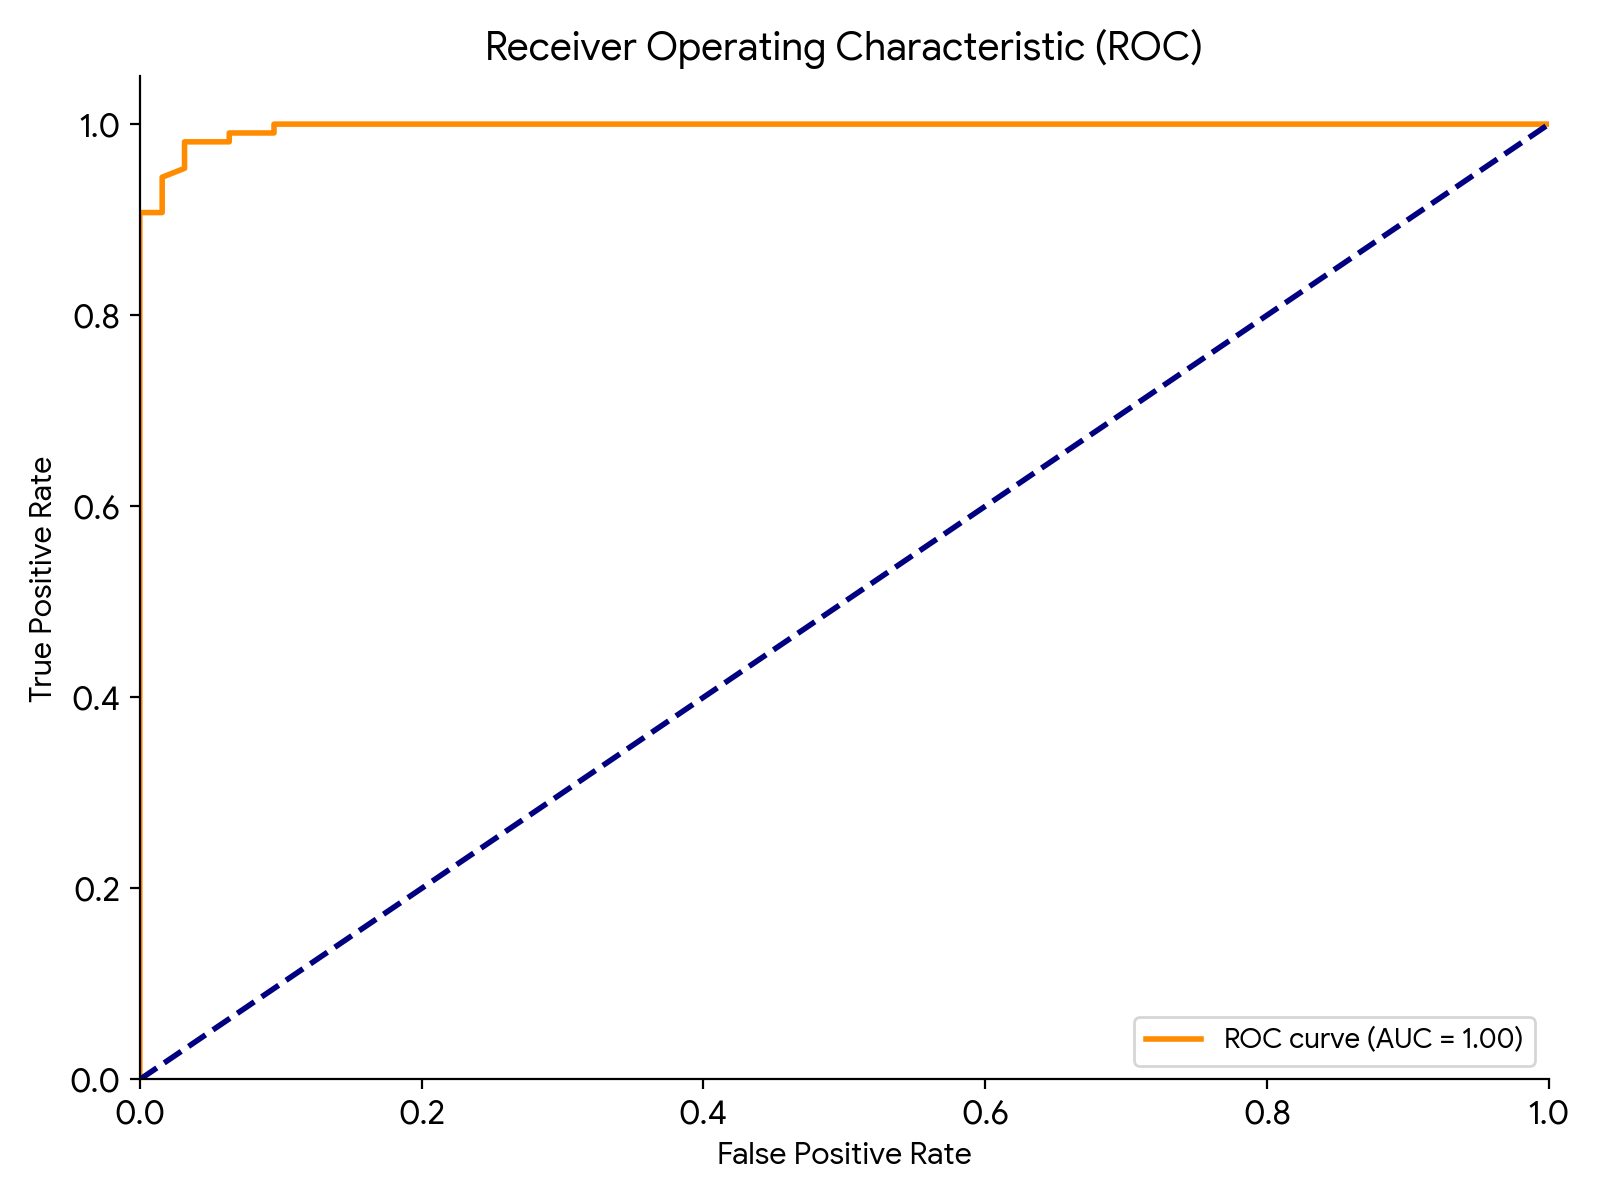

In [52]:
tools = [
    {'code_execution':{}},
    {'google_search':{}}
]
response = await chatting('Utiliza los datos que provee sklearn para entrenar un modelo de random forest en el set de cancer de mama. Muéstrame una gráfica de evaluación de un arbol aleatorio ', modality='TEXT', tools=tools)